In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
returns=pd.read_csv(
    "../data/daily_return.csv",
    index_col=0,
    parse_dates=True
)
returns.head()

,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-03,-0.009722,-0.012139,-0.005232,-0.012451,-0.016006
2020-01-06,0.007968,0.014886,0.026654,0.002584,0.004194
2020-01-07,-0.004703,0.002092,-0.001932,-0.009118,0.012107
2020-01-08,0.016086,-0.007809,0.007118,0.015928,0.001875
2020-01-09,0.021241,0.004799,0.010498,0.012493,0.010983


In [3]:
mean_returns=returns.mean()*252
mean_returns

AAPL     0.297892
AMZN     0.232658
GOOGL    0.257607
MSFT     0.248931
NVDA     0.768567
dtype: float64

In [4]:
cov_matrix=returns.cov()*252

In [5]:
num_assets=len(mean_returns)
num_assets

5

In [6]:
weights=np.random.random(num_assets)
weights/=np.sum(weights)
weights

array([0.07398152, 0.20114759, 0.15448201, 0.30248434, 0.26790454])

In [7]:
portfolio_return=np.dot(weights,mean_returns)

In [8]:
portfolio_risk=np.sqrt(
    np.dot(
    weights.T,
    np.dot(cov_matrix,weights)
)
)

In [9]:
risk_free_rate=0.04
sharpe=(
    portfolio_return-risk_free_rate)/portfolio_risk
sharpe



np.float64(1.064139327938619)

In [10]:
portfolio_returns=[]
portfolio_risks=[]
portfolio_sharpes=[]
portfolio_weights=[]

In [11]:
for i in range(10000):
    weights=np.random.random(num_assets)
    weights/=np.sum(weights)
    ret=np.dot(weights,mean_returns)
    risk=np.sqrt(
        np.dot(
           weights.T,
            np.dot(cov_matrix,weights)
        )
    )
    sharpe=(ret-risk_free_rate)/risk
    portfolio_returns.append(ret)
    portfolio_risks.append(risk)
    portfolio_sharpes.append(sharpe)
    portfolio_weights.append(weights)

    
    
    

In [12]:
results=pd.DataFrame({
    "Return": portfolio_returns,
    "Risk": portfolio_risks,
    "Sharpe": portfolio_sharpes
})
results.head()

,Return,Risk,Sharpe
0,0.254380,0.296126,0.723946
1,0.349556,0.309726,0.999450
2,0.362445,0.315070,1.023407
3,0.329580,0.301692,0.959855
4,0.415766,0.337234,1.114260


In [15]:
max_sharpe_idx=results["Sharpe"].idxmax()
best_portfolio=results.loc[max_sharpe_idx]
best_weights=portfolio_weights[max_sharpe_idx]
best_portfolio


Return    0.624857
Risk      0.442385
Sharpe    1.322055
Name: 1225, dtype: float64

In [16]:
min_risk_idx=results["Risk"].idxmin()
min_portfolio=results.loc[min_risk_idx]
min_weights=portfolio_weights[min_risk_idx]

min_portfolio

Return    0.264187
Risk      0.282128
Sharpe    0.794630
Name: 189, dtype: float64

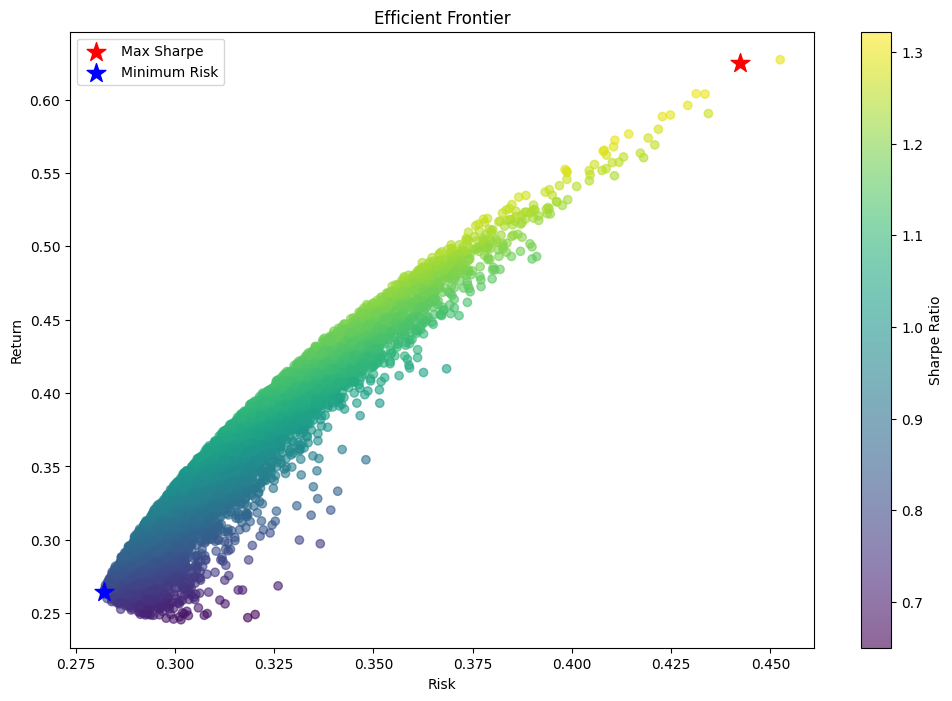

In [19]:
plt.figure(figsize=(12,8))

plt.scatter(
    portfolio_risks,
    portfolio_returns,
    c=portfolio_sharpes,
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Sharpe Ratio")

plt.scatter(
    best_portfolio["Risk"],
    best_portfolio["Return"],
    color="red",
    s=200,
    marker="*",
    label="Max Sharpe"
)

plt.scatter(
    min_portfolio["Risk"],
    min_portfolio["Return"],
    color="blue",
    s=200,
    marker="*",
    label="Minimum Risk"
)


plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.legend()
plt.show()






In [21]:
allocation=pd.DataFrame({
    "Stock":returns.columns,
    "Weight":best_weights
})
allocation

,Stock,Weight
0,AAPL,0.145833
1,AMZN,0.006946
2,GOOGL,0.125316
3,MSFT,0.014078
4,NVDA,0.707826
